# The Mandelbrot Set

## Mini-project step 1: Naive, NumPy, Numba

This project focuses on computing and visualizing the Mandelbrot set, which is a fractal defined over the complex plane. The set is defined by the quadratic complex mapping $z_{i+1} = z_i^2 + c$ starting from $z_0 = 0$. A complex point $c$ belongs to the Mandelbrot set if the sequence remains bounded. In practice, we use the threshold $|z| > 2$ because it is sufficient to guarantee divergence.

The computational domain is mapped over $\text{Re}(c) \in [-2, 1]$, $\text{Im}(c) \in [-1.5, 1.5]$. For visualization, we use the linear mapping $\mathcal{M}(c) = l(c)/I$, where $l(c)$ is the iteration at which the point escapes and $I$ is the maximum number of iterations. A small value indicates a highly unstable point and a value of 1 means the point never escaped and is considered stable. 

One reason the Mandelbrot set problem makes a good benchmark is that it is embarrassingly parallel, where each pixel is completely independent of all others, which makes it a natural candidate for testing how much vectorization and JIT compilation can help.

In [1]:
# Fixed boundary parameters
re_min, re_max = -2.0, 1.0
im_min, im_max = -1.5, 1.5

# Grid resolution and maximum iterations
p_re, p_im = 500, 500  
max_iter = 100

### 1. Implementations

#### 1.1 Naive Implementation

The first approach is the Naive version, which utilizes purely Python nested loops. For each grid point $c$, we initialize $z_{0}=0$ and iterate either the maximum number of iterations `max_iter` is reached or until the absolute value exceeds the threshold of 2. If that happens, the point escapes, and we break the loop to move to the next point.

This implementation is the simplest, but slow because the Python interpreter has to handle every single arithmetic operation one at a time.
Despite this, as we have seen in the first lecture, since NumPy arrays use row-major memory layout, the inner loop iterating over columns `j` writes to `M[i,j]` with unit stride, meaning consecutive writes land at consecutive memory addresses. This gives good spatial locality even in the naive version, keeping cache line waste low and making prefetching easier for the CPU.

In [2]:
import numpy as np
import time

def mandelbrot_naive(re_min, re_max, im_min, im_max, p_re, p_im, max_iter):
    M = np.zeros((p_im, p_re))
    
    re_step = (re_max - re_min) / (p_re - 1)
    im_step = (im_max - im_min) / (p_im - 1)
    
    for i in range(p_im):
        c_imag = im_min + i * im_step
        
        for j in range(p_re):
            c_real = re_min + j * re_step
            c = complex(c_real, c_imag)
            
            z = 0.0j
            escape_iter = max_iter 
            
            for k in range(max_iter):
                z = z*z + c
                if abs(z) > 2.0:
                    escape_iter = k + 1
                    break
                    
            M[i, j] = escape_iter / max_iter 
            
    return M

In [3]:
start_time_naive = time.time()
M_naive = mandelbrot_naive(re_min, re_max, im_min, im_max, p_re, p_im, max_iter)
end_time_naive = time.time()

exec_time_naive = end_time_naive - start_time_naive
print(f"Naive execution time for {p_re}x{p_im} grid: {exec_time_naive:.4f} seconds")

Naive execution time for 500x500 grid: 0.9524 seconds


#### 1.2 NumPy Vectorized Implementation
To improve performance, we replace the nested loops with a vectorized NumPy implementation. As explained in the second lecture, vectorization is the process of mapping loop-based scalar computations into operations performed on arrays, which is exactly what we do here. Instead of computing one point at a time, the entire complex grid is built at once using broadcasting, meaning that NumPy automatically replicates elements along a singleton dimension as needed. By reshaping the imaginary axis as `im[:, np.newaxis]` causes NumPy to automatically replicate its values across the second dimension, producing the full N×N grid of complex numbers without any explicit loop.

We also use a boolean mask to track which points have not yet escaped, updating only those at each iteration. This avoids wasted computation on escaped points and keeps the active working set smaller, which improves both temporal locality and memory efficiency as the resolution grows.

In [4]:
def mandelbrot_vectorized(re_min, re_max, im_min, im_max, p_re, p_im, max_iter):
    re = np.linspace(re_min, re_max, p_re)
    im = np.linspace(im_min, im_max, p_im)
    c = re + 1j * im[:, np.newaxis]
    
    z = np.zeros_like(c)
    M = np.zeros(c.shape, dtype=int)
    
    for k in range(max_iter):
        mask = np.abs(z) <= 2.0
        M[mask] = k + 1
        z[mask] = z[mask]**2 + c[mask]
        
    return M / max_iter

In [5]:
start_time_vectorized = time.time()
M_vectorized = mandelbrot_vectorized(re_min, re_max, im_min, im_max, p_re, p_im, max_iter)
end_time_vectorized = time.time()
exec_time_vectorized = end_time_vectorized - start_time_vectorized
print(f"Vectorized execution time for {p_re}x{p_im} grid: {exec_time_vectorized:.4f} seconds")

Vectorized execution time for 500x500 grid: 0.2660 seconds


#### 1.3 Numba JIT Implementation
The third implementation uses Numba's `@jit(nopython=True)` decorator to JIT-compile the naive version directly to machine code. 

As discussed in the second lecture, Numba performs just-in-time compilation, which eliminates Python interpreter overhead entirely, meaning that the function is compiled on its first call and runs as native code from that point on. For this reason a warm-up call is included before the actual benchmark so that compilation time does not contaminate the timing results.
This can lead to significant performance improvements, especially for computationally intensive tasks like the Mandelbrot set calculation. 

The Numba implementation retains the same algorithmic structure as the naive version but benefits from the speed of compiled code.

In [6]:
from numba import jit

@jit(nopython=True)
def mandelbrot_numba(re_min, re_max, im_min, im_max, p_re, p_im, max_iter):
    M = np.zeros((p_im, p_re))
    
    re_step = (re_max - re_min) / (p_re - 1)
    im_step = (im_max - im_min) / (p_im - 1)
    
    for i in range(p_im):
        c_imag = im_min + i * im_step
        
        for j in range(p_re):
            c_real = re_min + j * re_step
            c = complex(c_real, c_imag)
            
            z = 0.0j
            escape_iter = max_iter 
            
            for k in range(max_iter):
                z = z*z + c
                if abs(z) > 2.0:
                    escape_iter = k + 1
                    break
                    
            M[i, j] = escape_iter / max_iter 
            
    return M

In [7]:
_ = mandelbrot_numba(re_min, re_max, im_min, im_max, 10, 10, 10)

start_time_nb = time.time()
M_numba = mandelbrot_numba(re_min, re_max, im_min, im_max, p_re, p_im, max_iter)
end_time_nb = time.time()

exec_time_nb = end_time_nb - start_time_nb
print(f"Numba execution time for {p_re}x{p_im} grid: {exec_time_nb:.4f} seconds")

Numba execution time for 500x500 grid: 0.2086 seconds


#### 1.4 Visualization of the Mandelbrot Set
To verify that all three implementations produce consistent results and to give an intuitive picture of the problem we visualize their output side by side using a colormap. Points inside the Mandelbrot set (M=1) appear white while escaping points are colored by how quickly they diverge.

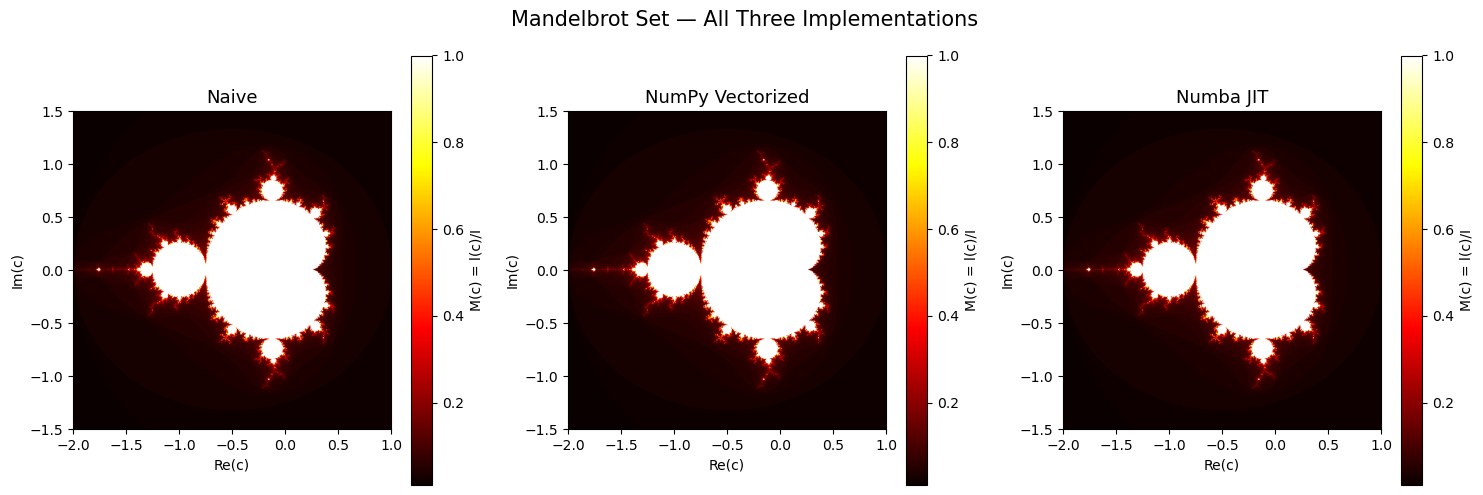

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

titles = ['Naive', 'NumPy Vectorized', 'Numba JIT']
matrices = [M_naive, M_vectorized, M_numba]

for ax, title, M in zip(axes, titles, matrices):
    im = ax.imshow(M, extent=[re_min, re_max, im_min, im_max],
                   origin='lower', cmap='hot', aspect='equal')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Re(c)')
    ax.set_ylabel('Im(c)')
    plt.colorbar(im, ax=ax, label='M(c) = l(c)/I')

plt.suptitle('Mandelbrot Set — All Three Implementations', fontsize=15)
plt.tight_layout()
plt.show()

### 2. Performance and Scaling Analysis

To evaluate how the three implementations scale with problem size we run all of them across a range of increasing grid resolutions and record the execution time at each step. 

The goal is to reach resolutions where the naive version takes a significant amount of time so that the performance differences become clearly visible. 

Results are stored in a DataFrame, speedup ratios are computed and everything is exported to CSV. Finally, we visualize the results using a line chart to clearly illustrate the performance differences and scalability of each approach.

#### 2.1 Benchmarking Methodology

The approach follows the principle stated in the second lecture: never optimize blindly, always profile first. 

To perform the scaling analysis, we start from small resolutions and gradually increase $N$ until the naive implementation is clearly slow. 

All three versions are tested with the same fixed parameters throughout defined in the beginning (the region $\text{Re}(c) \in [-2, 1]$, $\text{Im}(c) \in [-1.5, 1.5]$ with `max_iter = 100`) to keep the comparison fair. 

For Numba a warm-up call is always run before the timed measurement to ensure compilation time is not included in the final metrics.

In [9]:
import pandas as pd

resolutions = [100, 300, 600, 1000, 1500, 2000, 2500, 3000, 3500, 4000]
results = []

print("Starting performance analysis across different resolutions...")

for N in resolutions:
    print(f"Testing resolution: {N}x{N}")
    
    t0 = time.time()
    _ = mandelbrot_naive(re_min, re_max, im_min, im_max, N, N, max_iter)
    t_naive = time.time() - t0
    
    t0 = time.time()
    _ = mandelbrot_vectorized(re_min, re_max, im_min, im_max, N, N, max_iter)
    t_numpy = time.time() - t0
    
    t0 = time.time()
    _ = mandelbrot_numba(re_min, re_max, im_min, im_max, N, N, max_iter)
    t_numba = time.time() - t0
    
    results.append({
        'Resolution (NxN)': N,
        'Naive Time (s)': t_naive,
        'NumPy Time (s)': t_numpy,
        'Numba Time (s)': t_numba
    })

df_results = pd.DataFrame(results)

df_results['Speedup NumPy vs Naive'] = (
    df_results['Naive Time (s)'] / df_results['NumPy Time (s)']
).round(2)

df_results['Speedup Numba vs Naive'] = (
    df_results['Naive Time (s)'] / df_results['Numba Time (s)']
).round(2)

df_results['Speedup Numba vs NumPy'] = (
    df_results['NumPy Time (s)'] / df_results['Numba Time (s)']
).round(2)

print("Speedup Analysis:")
display(df_results)

df_results.to_csv('timing_results.csv', index=False)

Starting performance analysis across different resolutions...
Testing resolution: 100x100
Testing resolution: 300x300
Testing resolution: 600x600
Testing resolution: 1000x1000
Testing resolution: 1500x1500
Testing resolution: 2000x2000
Testing resolution: 2500x2500
Testing resolution: 3000x3000
Testing resolution: 3500x3500
Testing resolution: 4000x4000
Speedup Analysis:


,Resolution (NxN),Naive Time (s),NumPy Time (s),Numba Time (s),Speedup NumPy vs Naive,Speedup Numba vs Naive,Speedup Numba vs NumPy
0,100,0.036177,0.009836,0.003042,3.68,11.89,3.23
1,300,0.348772,0.071480,0.026035,4.88,13.40,2.75
2,600,1.322645,0.303283,0.102226,4.36,12.94,2.97
3,1000,3.682005,0.903363,0.278743,4.08,13.21,3.24
4,1500,8.163563,2.024575,0.621469,4.03,13.14,3.26
5,2000,14.652525,3.517141,1.095192,4.17,13.38,3.21
6,2500,22.686161,5.484009,1.714638,4.14,13.23,3.20
7,3000,32.792720,8.811388,2.465659,3.72,13.30,3.57
8,3500,44.543030,12.467220,3.351670,3.57,13.29,3.72
9,4000,58.915775,16.131708,4.364958,3.65,13.50,3.70


#### 2.2. Experimental Results

The scaling plot confirms what we expected: the naive execution time grows quadratically with $N$, since doubling the resolution quadruples the number of pixels and total work scales as $O(N^2)$. 
NumPy and Numba both remain far flatter, with Numba consistently ahead of NumPy at every resolution.

The speedup chart makes this gap more visible. Both speedups tend to grow with $N$, though the Numba advantage becomes especially pronounced at larger grid sizes.

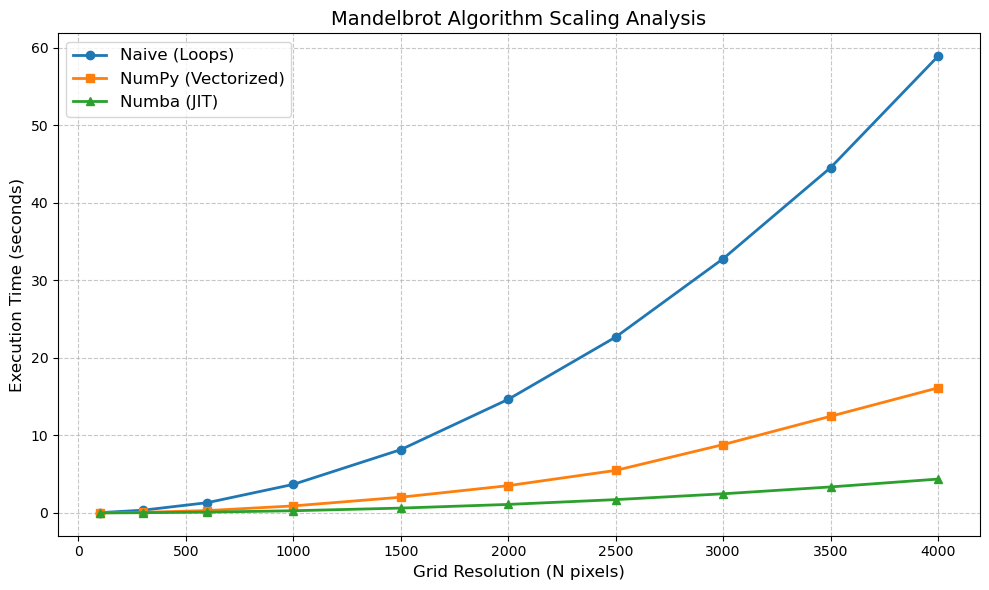

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(df_results['Resolution (NxN)'], df_results['Naive Time (s)'], marker='o', label='Naive (Loops)', linewidth=2)
plt.plot(df_results['Resolution (NxN)'], df_results['NumPy Time (s)'], marker='s', label='NumPy (Vectorized)', linewidth=2)
plt.plot(df_results['Resolution (NxN)'], df_results['Numba Time (s)'], marker='^', label='Numba (JIT)', linewidth=2)

plt.title('Mandelbrot Algorithm Scaling Analysis', fontsize=14)
plt.xlabel('Grid Resolution (N pixels)', fontsize=12)
plt.ylabel('Execution Time (seconds)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

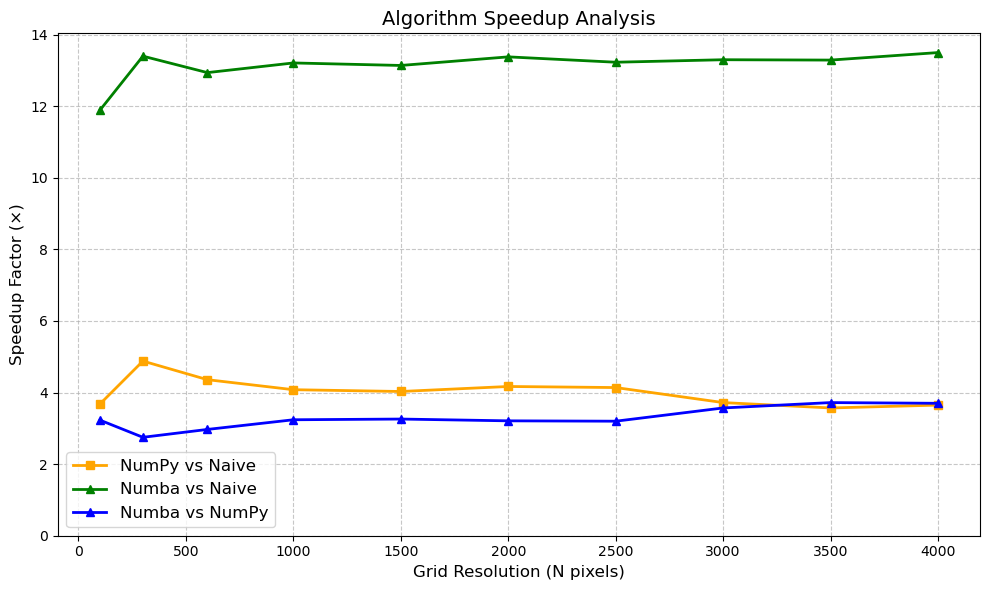

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(df_results['Resolution (NxN)'], 
         df_results['Speedup NumPy vs Naive'], 
         marker='s', label='NumPy vs Naive', linewidth=2, color='orange')
plt.plot(df_results['Resolution (NxN)'], 
         df_results['Speedup Numba vs Naive'], 
         marker='^', label='Numba vs Naive', linewidth=2, color='green')
plt.plot(df_results['Resolution (NxN)'], 
         df_results['Speedup Numba vs NumPy'], 
         marker='^', label='Numba vs NumPy', linewidth=2, color='blue')
plt.title('Algorithm Speedup Analysis', fontsize=14)
plt.xlabel('Grid Resolution (N pixels)', fontsize=12)
plt.ylabel('Speedup Factor (×)', fontsize=12)
plt.ylim(bottom=0)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Reasoning and Interpretation of Results

The performance differences between the three implementations can be explained by looking at how each one interacts with the underlying hardware architecture.

The main bottleneck of the Naive version, so pure Python, is interpreter overhead. Every arithmetic operation inside the nested loops is dispatched dynamically, which adds significant per-operation cost regardless of how simple the computation is. This is a well-known issue with tight scalar loops in Python and is entirely independent of the algorithm itself.

As explained in the second lecture, algorithmic intensity describes the amount of floating-point operations relative to the total number of bytes processed by an algorithm, and it is defined as $\beta_\text{alg} = F_\text{alg} / D_\text{alg}$ in FLOP/B. While floating-point operations are critical, most modern processors and algorithms lead to memory bound computations, meaning the hardware can deliver more floating-point performance than data can be transferred to the ALU(s). 
For our Mandelbrot kernel with `max_iter = 100`, each pixel requires roughly 6 FLOPs per iteration, since we have a complex multiply, an addition and a magnitude check. This gives us $F_\text{alg} \approx N^2 \times 600$ FLOP. The output is one double-precision float per pixel, so $D_\text{alg} \approx N^2 \times 8$ B, which yields:

$$\beta_\text{alg} \approx \frac{600}{8} \approx 75 \ \text{FLOP/B}$$

Since the hardware intensity of a typical CPU is around $\beta_\text{hw} \approx 3$–$7$ FLOP/B (as said in the second lecture), we have $\beta_\text{alg} \gg \beta_\text{hw}$, which means the kernel is compute-bound, so the CPU's ALUs are the bottleneck, not memory bandwidth.

This is why the Naive version is slow because it is interpreted and has very low hardware utilization, while the Numba version is fast because it achieves the largest speedups by compiling directly to machine code, which allows the CPU to exploit instruction-level parallelism, pipelining and out-of-order execution as discussed in the first lecture. This keeps intermediate values like $z$ and $c$ in fast hardware registers rather than fetching them from memory on every iteration.

As steted in the first lecture, memory access is today the most critical issue for overall computing performance. When the CPU needs data, it checks the fast local L1/L2/L3 caches and if data is not found in cache, it is a cache miss.
Our NumPy implementation heavily mitigates this by applying boolean masks. By cutting out pixels that have already escaped the threshold, we avoid useless computations and unnecessary memory writes. This keeps the active working dataset smaller and closer to the CPU, exploiting Temporal Locality so that the data stays in cache as long as we are using them. It also exploits Spatial Locality by performing contiguous array operations rather than fragmented data fetching, avoiding the penalties of long striding, so accessing every nth element in memory.

That said, at larger resolutions NumPy starts to lose some ground relative to Numba. A 2500×2500 matrix of doubles already occupies around 50 MB, well beyond L2/L3 cache capacity. On top of that, the boolean mask arrays add extra memory pressure, competing with the main output matrix for cache space and causing capacity cache misses as described in the first lecture. Numba avoids this entirely thanks to its scalar JIT-compiled loop that never allocates large intermediate arrays, so it stays consistently ahead even at the largest grid sizes we tested.
